In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

In [7]:
df=pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.info

<bound method DataFrame.info of         encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)      ?   
1             149190     55629189        Caucasian  Female  [10-20)      ?   
2              64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3             500364     82442376        Caucasian    Male  [30-40)      ?   
4              16680     42519267        Caucasian    Male  [40-50)      ?   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)      ?   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)      ?   
101763     443854148     41088789        Caucasian    Male  [70-80)      ?   
101764     443857166     31693671        Caucasian  Female  [80-90)      ?   
101765     443867222    175429310        Caucasian    Male  [70-80)      ?   

        admission_type_id  disc

In [ ]:
#dataset:Diabeties 130 us hospitals 1999-2008
#goal:to analyse readmission

In [12]:
df.shape


(101766, 50)

In [14]:
df.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [15]:
df.isnull().sum()


encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [18]:
df.replace("?",pd.NA,inplace=True)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [19]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
df_raw=df.copy()#saved original data set as df_raw

In [21]:
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [22]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [23]:
df.drop(columns=["encounter_id","patient_nbr"],inplace=True)

In [24]:
df.nunique().sort_values()

examide                       1
citoglipton                   1
acetohexamide                 2
tolbutamide                   2
diabetesMed                   2
troglitazone                  2
metformin-rosiglitazone       2
metformin-pioglitazone        2
glipizide-metformin           2
glimepiride-pioglitazone      2
change                        2
gender                        3
max_glu_serum                 3
readmitted                    3
tolazamide                    3
A1Cresult                     3
glyburide-metformin           4
acarbose                      4
rosiglitazone                 4
insulin                       4
miglitol                      4
repaglinide                   4
chlorpropamide                4
nateglinide                   4
metformin                     4
glyburide                     4
glipizide                     4
glimepiride                   4
pioglitazone                  4
race                          5
num_procedures                7
admissio

In [25]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),<NA>,6,25,1,1,<NA>,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),<NA>,1,1,7,3,<NA>,<NA>,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,<NA>,<NA>,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),<NA>,1,1,7,2,<NA>,<NA>,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),<NA>,1,1,7,1,<NA>,<NA>,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [26]:
df["examide"]

0         No
1         No
2         No
3         No
4         No
          ..
101761    No
101762    No
101763    No
101764    No
101765    No
Name: examide, Length: 101766, dtype: object

In [33]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [ ]:

df.isnull().sum().sort_values(ascending=False).head(10)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
time_in_hospital         0
dtype: int64

In [40]:
#dropping columns which have more null values
df.drop(columns=["weight","max_glu_serum","A1Cresult"],inplace=True)

In [41]:
df["weight"]

KeyError: 'weight'

In [42]:
df["medical_specialty"]

0         Pediatrics-Endocrinology
1                             <NA>
2                             <NA>
3                             <NA>
4                             <NA>
                    ...           
101761                        <NA>
101762                        <NA>
101763                        <NA>
101764             Surgery-General
101765                        <NA>
Name: medical_specialty, Length: 101766, dtype: object

In [43]:
df["medical_specialty"].value_counts()

medical_specialty
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099
                          ...  
Proctology                    1
Speech                        1
SportsMedicine                1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 72, dtype: int64

In [44]:
df["medical_specialty"].fillna("Unknown",inplace=True)

In [45]:
df["payer_code"].fillna("Unknown",inplace=True)

In [47]:
df[["race","diag_1","diag_2","diag_3"]]=df[["race","diag_1","diag_2","diag_3"]].fillna("Unknown")

In [48]:
df.isnull().sum().sort_values(ascending=False).head(10)

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
dtype: int64

In [49]:
df["age"].value_counts().sort_values()


age
[0-10)        161
[10-20)       691
[20-30)      1657
[90-100)     2793
[30-40)      3775
[40-50)      9685
[80-90)     17197
[50-60)     17256
[60-70)     22483
[70-80)     26068
Name: count, dtype: int64

In [53]:
df["age"].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

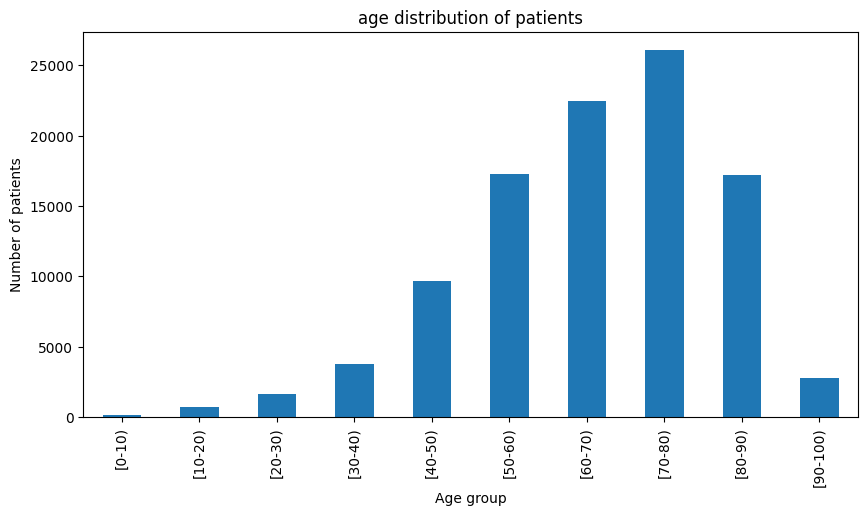

In [59]:
import matplotlib.pyplot as plt

df["age"].value_counts().sort_index().plot(kind="bar",figsize=(10,5))
plt.title("age distribution of patients")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.show()


In [62]:
#age vs readmission risk
pd.crosstab(df["age"],df["readmitted"],margins=True)

readmitted,<30,>30,NO,All
age,,,,
[0-10),3,26,132,161
[10-20),40,224,427,691
[20-30),236,510,911,1657
[30-40),424,1187,2164,3775
[40-50),1027,3278,5380,9685
[50-60),1668,5917,9671,17256
[60-70),2502,7897,12084,22483
[70-80),3069,9475,13524,26068
[80-90),2078,6223,8896,17197


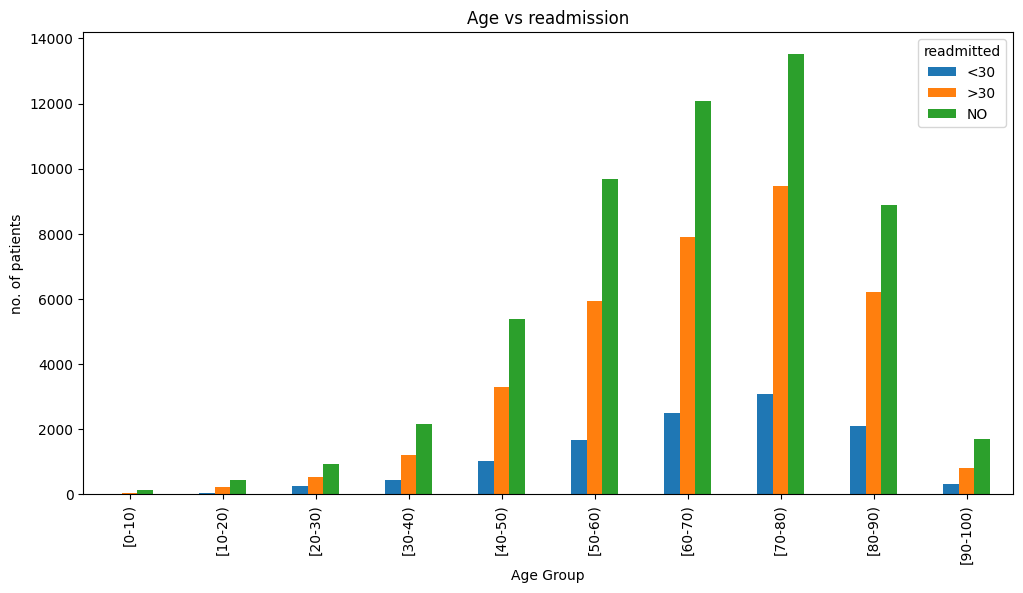

In [66]:
pd.crosstab(df["age"],df["readmitted"]).plot(kind='bar',figsize=(12,6))
plt.title("Age vs readmission")
plt.xlabel("Age Group")
plt.ylabel("no. of patients")
plt.show()

In [72]:
#gender vs readmission
pd.crosstab(df["gender"],df["readmitted"],margins=True)

readmitted,<30,>30,NO,All
gender,,,,
Female,6152,19518,29038,54708
Male,5205,16027,25823,47055
Unknown/Invalid,0,0,3,3
All,11357,35545,54864,101766


In [77]:
re=pd.crosstab(df["gender"],df["readmitted"])
re["admitted!"]=re["<30"]+re[">30"]
re

readmitted,<30,>30,NO,admitted!
gender,,,,
Female,6152,19518,29038,25670
Male,5205,16027,25823,21232
Unknown/Invalid,0,0,3,0


In [83]:
re["readmission_rate"]=re["admitted!"]/(re["admitted!"]+re["NO"])*100
re

readmitted,<30,>30,NO,admitted!,readmission_rate
gender,,,,,
Female,6152,19518,29038,25670,46.921840
Male,5205,16027,25823,21232,45.121666
Unknown/Invalid,0,0,3,0,0.000000


In [88]:
#readmission rate in specific gender

re["readmission_rate_in_specific_gender"]=re["admitted!"]/re.sum(axis=1)*100
re

readmitted,<30,>30,NO,admitted!,readmission_rate,readmission_rate_in_specific_gender
gender,,,,,,
Female,6152,19518,29038,25670,46.921840,31.917840
Male,5205,16027,25823,21232,45.121666,31.071629
Unknown/Invalid,0,0,3,0,0.000000,0.000000


In [90]:
#hospital stay vs age
df.groupby("readmitted")["time_in_hospital"].mean()

readmitted
<30    4.768249
>30    4.495541
NO     4.254429
Name: time_in_hospital, dtype: float64

In [92]:
df["time_in_hospital"]

0          1
1          3
2          2
3          2
4          1
          ..
101761     3
101762     5
101763     1
101764    10
101765     6
Name: time_in_hospital, Length: 101766, dtype: int64

In [93]:
df["time_in_hospital"].nunique()

14

In [95]:
pd.crosstab(df["time_in_hospital"],df["readmitted"],normalize="index")*100

readmitted,<30,>30,NO
time_in_hospital,,,
1,8.178491,31.468187,60.353322
2,9.939619,34.364840,55.695541
3,10.666817,34.270106,55.063077
4,11.806952,36.368860,51.824188
5,12.030905,35.982340,51.986755
6,12.587876,36.543308,50.868815
7,12.834955,36.234852,50.930193
8,14.233660,36.187657,49.578684
9,13.724184,36.608927,49.666889


Text(0, 0.5, 'readmission')

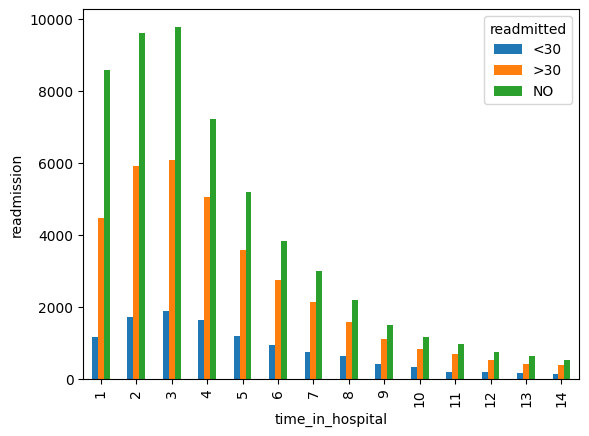

In [102]:
pd.crosstab(df["time_in_hospital"],df["readmitted"]).plot(kind="bar")
plt.ylabel("readmission")
#import seaborn as sns
#sns.countplot(x="time_in_hospital",hue="readmitted",data=df)

Text(0, 0.5, 'readmission')

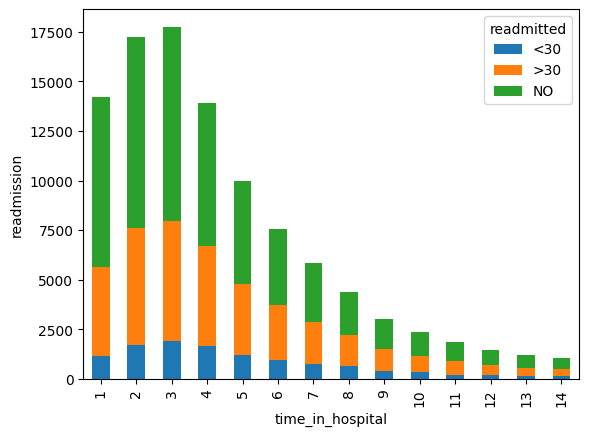

In [103]:
pd.crosstab(df["time_in_hospital"],df["readmitted"]).plot(kind="bar",stacked="True")
plt.ylabel("readmission")


<Axes: xlabel='time_in_hospital', ylabel='count'>

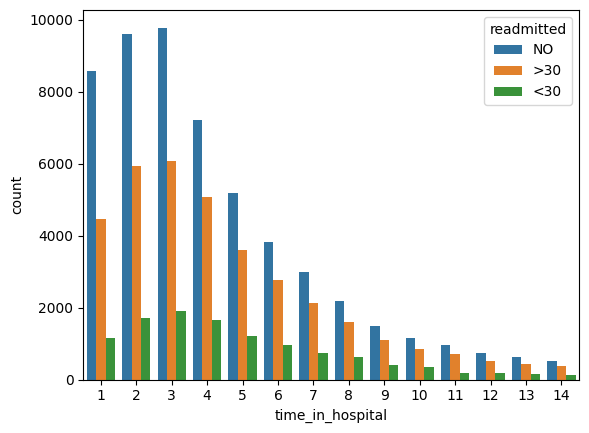

In [100]:
import seaborn as sns
sns.countplot(x="time_in_hospital",hue="readmitted",data=df)

In [ ]:
df.groupby("readmitted")["time_in_hospital"].mean()
#pd.crosstab(df["readmitted"],df["time_in_hospital"],margins=True) thought to do but the above is best

readmitted
<30    4.768249
>30    4.495541
NO     4.254429
Name: time_in_hospital, dtype: float64

Text(0, 0.5, 'avg days in hospital')

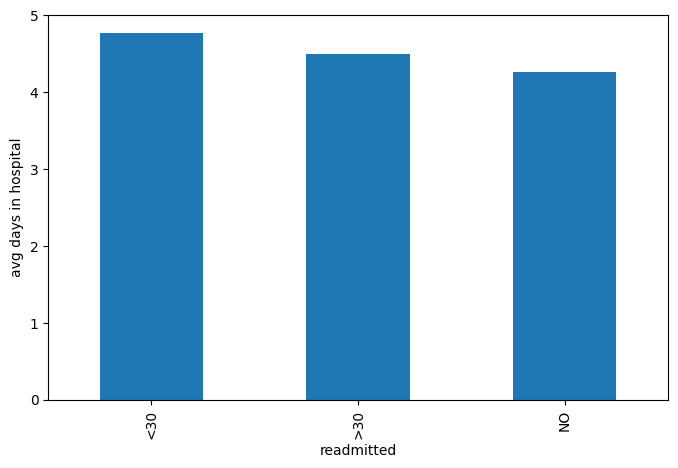

In [109]:
df.groupby("readmitted")["time_in_hospital"].mean().plot(kind="bar",figsize=(8,5))
plt.ylabel("avg days in hospital")

In [110]:
#no. of lab tests vs readmission
#this make sure us to interpret better diagnosis reduces readmission

<Axes: xlabel='readmitted'>

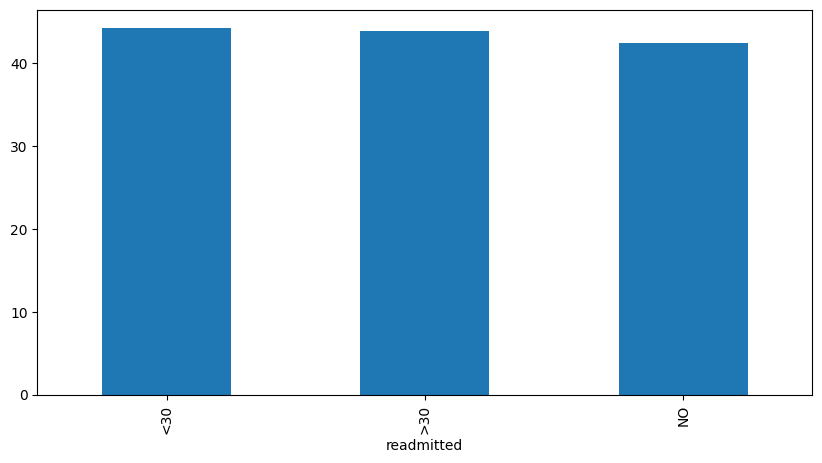

In [ ]:
df.groupby("readmitted")["num_lab_procedures"].mean().plot(kind="bar",figsize=(10,5))
plt.ylabel("lab_procedures")

In [115]:
#medications vs readmission
df.groupby("readmitted")["num_medications"].mean()

readmitted
<30    16.903143
>30    16.282768
NO     15.670367
Name: num_medications, dtype: float64

Text(0, 0.5, 'avg medications')

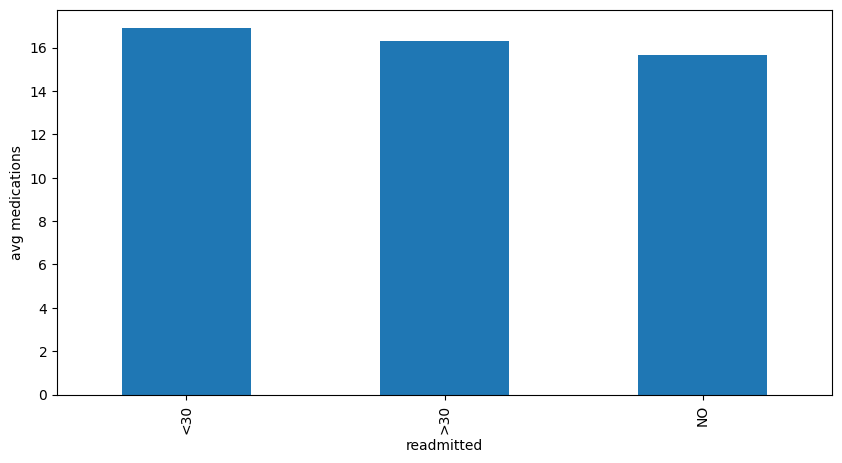

In [116]:
df.groupby("readmitted")["num_medications"].mean().plot(kind="bar",figsize=(10,5))
plt.ylabel("avg medications")

In [125]:
#predicting readmission!!! ML 
df["readmitted_binary"]=df["readmitted"].apply(lambda x:1 if x=="<30" else 0)
df[["readmitted_binary"]].value_counts()


readmitted_binary
0                    90409
1                    11357
Name: count, dtype: int64

In [126]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

X = df[features]
y = df["readmitted_binary"]

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [128]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [130]:
y_pred = model.predict(X_test)


In [131]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8873440110052078

In [133]:
df.to_csv("cleaned_healthcare_data.csv", index=False)

In [135]:
X_test["actual"] = y_test
X_test["predicted"] = y_pred

X_test.to_csv("readmission_predictions.csv", index=False)


In [136]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18032    37]
 [ 2256    29]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.44      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [141]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test[X.columns])

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8699027218237202


In [142]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False)

num_lab_procedures    0.417375
num_medications       0.258728
time_in_hospital      0.115536
num_procedures        0.078805
number_inpatient      0.059261
number_outpatient     0.043472
number_emergency      0.026822
dtype: float64

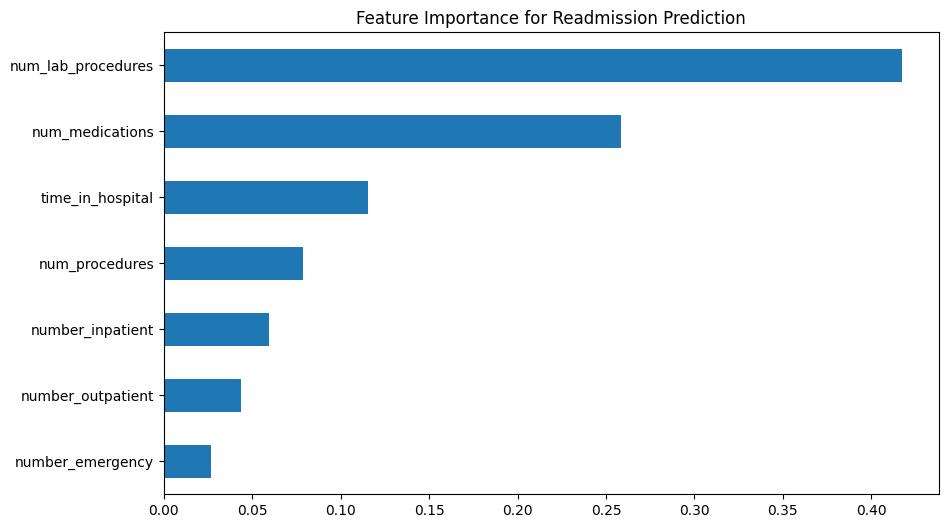

In [143]:
importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance for Readmission Prediction")
plt.show()

In [144]:
df["readmission_risk"] = rf.predict_proba(X)[:,1]

In [145]:
def risk_level(x):
    if x > 0.7:
        return "High Risk"
    elif x > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_category"] = df["readmission_risk"].apply(risk_level)

In [146]:
df.to_csv("final_healthcare_analysis.csv", index=False)